In [ ]:
import random
import numpy as np

random.seed(42)
np.random.seed(42)

import pandas as pd

In [25]:
appdata = pd.read_csv('../Output/london_app_selected_converted.csv')

In [26]:
appdata = appdata[~appdata['year'].isin([2000, 2001])]

In [27]:
appdata

,lsoa21cd,borough,year,description,decision,status,total_no_proposed_residential_units,wgs84_cleaned,geometry
8034,E01033084,Hounslow,2002,Change of use from guest house to 5 flats.,Approved,Lapsed,5,"[[[-0.36136, 51.464841], [-0.361361, 51.464814...",POINT (-0.361382 51.46482749999999)
8035,E01002676,Hounslow,2002,Demolition of existing house and erection of 4...,NaN,Completed,4,"[[[-0.354684, 51.48355], [-0.354685, 51.483523...",POINT (-0.3547059999999991 51.483537)
8036,E01002662,Hounslow,2002,Erection of single storey rear extension and c...,NaN,Completed,2,"[[[-0.36847, 51.470524], [-0.368471, 51.470497...",POINT (-0.3684925000000009 51.47051100000001)
8037,E01002687,Hounslow,2002,Change of use from office to 2 bed maisonette.,NaN,Completed,1,"[[[-0.269673, 51.489476], [-0.269674, 51.48944...",POINT (-0.269695 51.4894625)
8038,E01002649,Hounslow,2002,Conversion from retail unit to 1 bed flat and ...,NaN,Completed,2,"[[[-0.362812, 51.464897], [-0.362813, 51.46487...",POINT (-0.36283386491228 51.464883746491225)
...,...,...,...,...,...,...,...,...,...
122017,E01000638,Brent,2021,Change of use of first and second floors offic...,Refused,Refused,8,"[[(-0.24395448409224368, 51.54877433279962), (...",POINT (-0.2434823936232951 51.54850789705744)
122018,E01000488,Brent,2021,Certificate of lawfulness for existing use as ...,Approved,Commenced,7,"[[(-0.2276642681478578, 51.54690131880965), (-...",POINT (-0.2279109861174194 51.54677001691387)
122019,E01034149,Croydon,2021,Erection of mansard roof over whole building t...,NaN,Completed,12,"[[[-0.095991, 51.369057], [-0.096279, 51.36903...",POINT (-0.0960749645169064 51.36889068016831)
122020,E01000643,Brent,2021,Prior approval for the construction of new dwe...,Approved,Completed,2,"[[(-0.23840898252872503, 51.54535227974506), (...",POINT (-0.2382511927431808 51.54533609304931)


In [28]:
nan_count_description = appdata['description'].isna().sum()
print(nan_count_description)

48


In [29]:
nan_count_decision = appdata['decision'].isna().sum()
print(nan_count_decision)

89577


In [30]:
nan_count_status = appdata['status'].isna().sum()
print(nan_count_status)

53


In [31]:
counts_d = appdata['decision'].value_counts()
print(counts_d)

decision
Approved                                 20810
Refused                                   2236
Comment Issued                             512
Withdrawn                                  273
Not Required                               175
REFUSED                                     87
GWLA                                        79
Closed                                      70
Declined to Determine                       52
Allowed                                     49
Called in by Secretary of State             24
GWGC                                        16
Opinion Issued                               8
WDNA                                         6
No Objection to Proposal (OBS only)          3
Referred to Mayor                            3
Pre-application Advice Case Completed        2
Split Decision                               1
GWUU                                         1
PER                                          1
LAPSED                                       1
Unkn

In [32]:
counts_s = appdata['status'].value_counts()
print(counts_s)

status
Completed                          69197
Lapsed                             17255
Superseded                         13674
Commenced                           9097
Approved                            2113
Refused                              994
Unknown                              372
Dismissed                            371
Withdrawn                            251
Closed                               188
Allowed                               64
REFUSED                               53
Appeal In Progress                    53
Appeal in Progress                    37
Not Required                          37
lapsed                                37
Insufficient Fee                      23
Called in by Secretary of State       20
Application Under Consideration       12
                                      11
CGP                                   10
Comment Issued                        10
GRANTD                                 8
Appeal Closed                          6
GRANT    

In [33]:
# Count total number of rows in the dataset
total_count = len(appdata)

# Count how many rows have NaN (missing) values in 'description'
missing_count = appdata['description'].isna().sum()

# Fill NaNs with empty string and convert everything to string type
appdata['description_str'] = appdata['description'].notna().fillna('').astype(str)

# Count how many rows are empty strings (or only whitespace)
empty_string_count = (appdata['description_str'].str.strip() == '').sum()

# Print summary
print(f"Total rows: {total_count}")
print(f"NaN description rows: {missing_count} ({missing_count / total_count:.2%})")
print(f"Empty string description rows: {empty_string_count} ({empty_string_count / total_count:.2%})")

Total rows: 113988
NaN description rows: 48 (0.04%)
Empty string description rows: 0 (0.00%)


In [34]:
appdata.dropna(subset=['description'], inplace=True)
appdata.drop(columns=['description_str'], inplace=True)

In [35]:
import re

def clean_text(text):
    # Remove line breaks and other control characters
    text = re.sub(r"[\r\n\t]+", " ", text)
    
    # Merge multiple spaces
    text = re.sub(r"\s{2,}", " ", text)

    text = text.strip()

    # If the end of the test is not punctuation (.?!), add a period
    if text and text[-1] not in ".?!":
        text += "."

    return text

appdata['description_clean'] = appdata['description'].fillna("").apply(clean_text)

In [ ]:
agg_text_train = appdata[['lsoa21cd', 'year', 'description_clean']]

In [ ]:
agg_text_train

,lsoa21cd,year,description_clean
8034,E01033084,2002,Change of use from guest house to 5 flats.
8035,E01002676,2002,Demolition of existing house and erection of 4...
8036,E01002662,2002,Erection of single storey rear extension and c...
8037,E01002687,2002,Change of use from office to 2 bed maisonette.
8038,E01002649,2002,Conversion from retail unit to 1 bed flat and ...
...,...,...,...
122017,E01000638,2021,Change of use of first and second floors offic...
122018,E01000488,2021,Certificate of lawfulness for existing use as ...
122019,E01034149,2021,Erection of mansard roof over whole building t...
122020,E01000643,2021,Prior approval for the construction of new dwe...


In [38]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(stop_words='english' , ngram_range=(1,2))
X = cv.fit_transform(agg_text_train['description_clean'])
print("Total unique tokens:", len(cv.get_feature_names_out()))

Total unique tokens: 225711


In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

print(sorted(ENGLISH_STOP_WORDS))

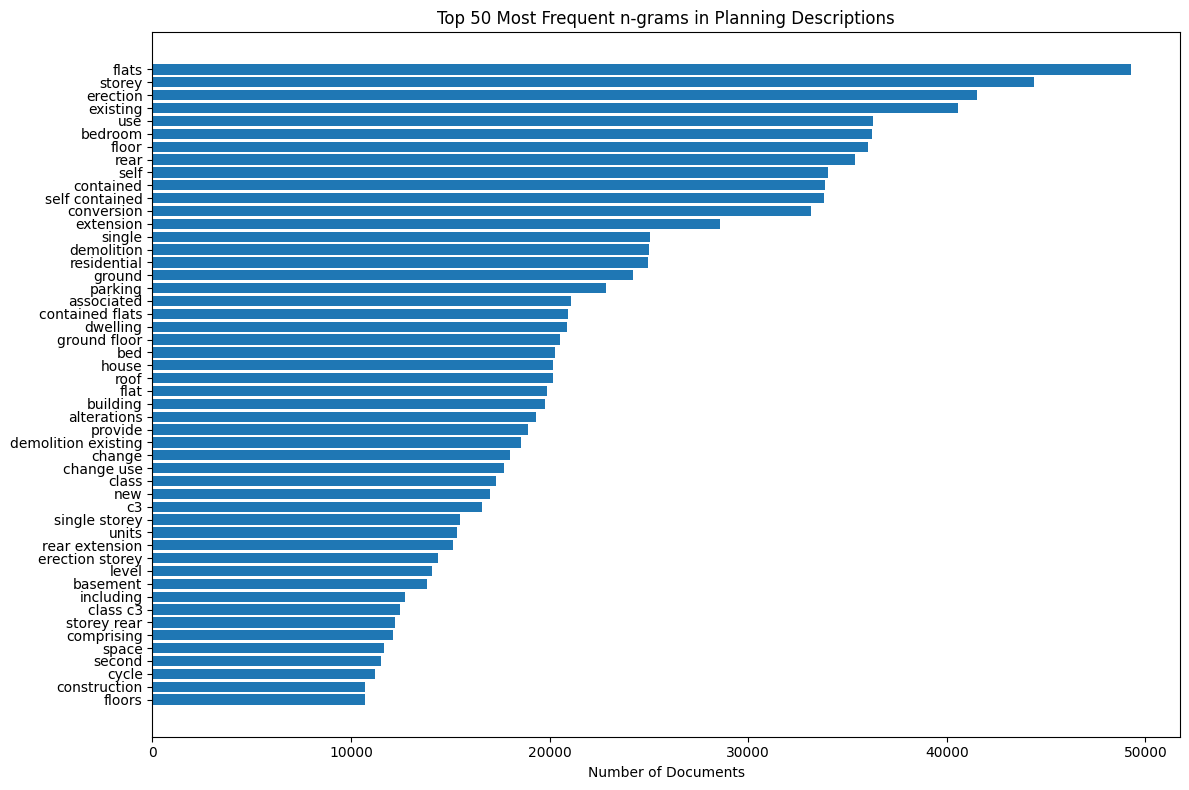

In [ ]:
import matplotlib.pyplot as plt

# Convert planning descriptions into a list of documents
docs = agg_text_train['description_clean'].tolist()

# Create a CountVectorizer to extract unigrams and bigrams, excluding English stopwords
vectorizer = CountVectorizer(
    stop_words='english',
    ngram_range=(1, 2)  # Extract both unigrams and bigrams
)

# Generate the document-term matrix (rows = documents, columns = n-grams)
X = vectorizer.fit_transform(docs)

# Get the list of extracted n-grams
ngrams = vectorizer.get_feature_names_out()

# Compute document frequency for each n-gram
doc_freq = (X > 0).sum(axis=0).A1  # .A1 flattens the sparse matrix to a 1D array

# Create a DataFrame containing n-grams and their corresponding document frequencies
df_freq = pd.DataFrame({
    'ngram': ngrams,
    'doc_freq': doc_freq
})

# Sort by document frequency and select the top 50 most frequent n-grams
df_freq_sorted = df_freq.sort_values(by='doc_freq', ascending=False).head(50)

# Visualize the top 50 n-grams using a horizontal bar chart
plt.figure(figsize=(12, 8))
plt.barh(df_freq_sorted['ngram'][::-1], df_freq_sorted['doc_freq'][::-1])  # Reverse for top-down order
plt.xlabel("Number of Documents", fontsize=12, fontweight='bold')
plt.title("Top 50 Most Frequent n-grams in Planning Descriptions", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [40]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN

from sentence_transformers import SentenceTransformer

In [ ]:
docs = agg_text_train['description_clean'].tolist()

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

hdbscan_model = HDBSCAN(
    min_cluster_size=10,
    prediction_data=True,
    random_state=42
)

umap_model = UMAP(
    n_neighbors=15,
    n_components=5,
    min_dist=0.0,
    random_state=42
)

vectorizer_model = CountVectorizer(
    stop_words='english', 
    ngram_range=(1, 2),
    max_df=0.35                        
)

In [42]:
topic_model = BERTopic(
    language="english",
    embedding_model=embedding_model,
    calculate_probabilities=True,
    hdbscan_model=hdbscan_model,
    umap_model=umap_model,
    top_n_words=10,
    vectorizer_model=vectorizer_model
)
topics, probs = topic_model.fit_transform(docs)

In [43]:
topic_model.save("../Model/bertopic_mcs=10_ms=10_nn=15_nc=5_md=0.0_nr=1,2_mid=3_", save_embedding_model=True)

2025-07-11 15:23:37,594 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


In [44]:
topic_model.visualize_term_rank()

In [45]:
topic_model.top_n_words = 5

In [ ]:
def compute_topic_diversity_score(topic_model):
    """
    Compute topic diversity score as the ratio of unique keywords 
    to total keywords across all topics (excluding topic -1).
    """
    topics_ = topic_model.get_topics()
    all_words = [
        word for topic_id, words in topics_.items() if topic_id != -1
        for word, _ in words
    ]
    unique_words = set(all_words)
    return len(unique_words) / len(all_words) if all_words else 0

In [ ]:
from collections import Counter

def topic_model_analysis(topic_model, docs):
    """
    Analyze the BERTopic model:
    - Reports number of outliers (topic -1)
    - Computes topic diversity score
    - Prints topic summary table
    """
    # Get topic assignment info for each document
    df_info = topic_model.get_document_info(docs)
    
    # Outlier analysis
    total_docs = len(df_info)
    num_outliers = (df_info['Topic'] == -1).sum()
    outlier_ratio = num_outliers / total_docs

    print(f"Total documents: {total_docs}\n")
    print(f"Documents assigned to topic -1: {num_outliers} ({outlier_ratio:.2%})\n")

    # Topic diversity score
    diversity_score = compute_topic_diversity_score(topic_model)
    print(f"Topic Diversity Score: {diversity_score:.4f}\n")

    # Topic summary
    print("Topic Summary:")
    print(topic_model.get_topic_info())

In [47]:
topic_model_analysis(topic_model, docs)

Total documents: 113940
Documents assigned to topic -1: 48199 (42.30%)

Topic Diversity Score: 0.4598

Topic Summary:
      Topic  Count                                               Name  \
0        -1  48199                  -1_rear_ground_floor_ground floor   
1         0   2826  0_maisonette_floor maisonette_bedroom maisonet...   
2         1   2659  1_storey building_building comprising_erection...   
3         2   1810  2_mansard roof_mansard_erection mansard_roof e...   
4         3   1518    3_class b1_office class_c3 change_offices class   
...     ...    ...                                                ...   
1090   1089     10  1089_cockfosters_cockfosters road_blackhorse_h...   
1091   1090     10  1090_flats retrospective_retrospective convers...   
1092   1091     10  1091_dwelling self_slopes associated_rooflight...   
1093   1092     10  1092_road exit_access plough_existing warehous...   
1094   1093     10  1093_level studio_accomodation provide_facade ...   

     

In [48]:
embeddings = embedding_model.encode(docs, show_progress_bar=True)

# Reduce embeddings to 2D
reduced_embeddings = UMAP(n_neighbors=10, n_components=2,
                          min_dist=0.0, metric='cosine').fit_transform(embeddings)

topic_model.visualize_documents(docs, reduced_embeddings=reduced_embeddings,
                                hide_document_hover=True, hide_annotations=True)

Batches:   0%|          | 0/3561 [00:00<?, ?it/s]

In [ ]:
def ctfidf_threshold_analysis(model, docs, topics, thresholds=[0.05, 0.1, 0.15, 0.2, 0.25]):

    ratios = []

    for t in thresholds:
        new_topics = model.reduce_outliers(docs, topics, strategy="c-tf-idf", threshold=t)
        outlier_ratio = (np.array(new_topics) == -1).sum() / len(new_topics)
        print(f"Threshold: {t} → Outlier ratio: {outlier_ratio:.2%}")
        ratios.append(outlier_ratio)

    plt.plot(thresholds, ratios, marker='o')
    plt.xlabel("Threshold", fontsize=12, fontweight='bold')
    plt.ylabel("Outlier Ratio", fontsize=12, fontweight='bold')
    plt.title("Outlier Ratio vs. c-tf-idf Threshold in reduce_outliers()", fontsize=16, fontweight='bold', pad=20)
    plt.grid(True)
    plt.show()

In [ ]:
model = BERTopic.load("../Model/bertopic_mcs=10_ms=10_nn=15_nc=5_md=0.0_nr=1,2_mid=3_")

ctfidf_threshold_analysis(model, docs, topics, thresholds=[0.05, 0.1, 0.15, 0.2, 0.25])

In [49]:
# Use the "c-TF-IDF" strategy with threshold 0.1
new_topics_cti = topic_model.reduce_outliers(docs, topics , strategy="c-tf-idf", threshold=0.1)

In [50]:
topic_model.update_topics(docs, topics=new_topics_cti)

2025-07-11 15:35:50,257 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


In [51]:
topic_model_analysis(topic_model, docs)

Total documents: 113940
Documents assigned to topic -1: 8784 (7.71%)

Topic Diversity Score: 0.4060

Topic Summary:
      Topic  Count                                             Name  \
0        -1   8784                      -1_street_road_new_building   
1         0   2881               0_maisonette_maisonettes_2nd_lower   
2         1   2696              1_building_comprising_plus_erection   
3         2   1981                   2_mansard_safety_roof_surround   
4         3   1641                        3_b1_office_class_offices   
...     ...    ...                                              ...   
1090   1089     17  1089_cockfosters_churchwood_blackhorse_holbrook   
1091   1090     70  1090_retrospective_application_summary_modified   
1092   1091     27             1091_chair_wheel_slopes_consultation   
1093   1092     17                1092_plough_exit_warehouse_marine   
1094   1093     29       1093_replacing_studio_worksto_accomodation   

                               

In [52]:
topic_model.visualize_documents(docs, reduced_embeddings=reduced_embeddings,
                                hide_document_hover=True, hide_annotations=True)

In [53]:
topic_model.save("../Model/bertopic_mcs=10_ms=10_nn=15_nc=5_md=0.0_nr=1,2_mid=3_updated_after_reduce_outliers", save_embedding_model=True)

2025-07-11 15:36:33,485 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


In [54]:
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

def compute_coherence_score(model, docs, top_n_words=10):
    """
    Compute topic coherence score using Gensim's CoherenceModel.
    """
    # Get top-n words for each topic
    topics = model.get_topics()
    topic_words = [
        [word for word, _ in words[:top_n_words]]
        for topic_id, words in topics.items()
        if topic_id != -1
    ]
    
    # Tokenize documents
    tokenized_docs = [doc.split() for doc in docs]
    
    # Prepare dictionary and corpus for CoherenceModel
    dictionary = Dictionary(tokenized_docs)
    
    coherence_model = CoherenceModel(
        topics=topic_words,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_v'
    )
    return coherence_model.get_coherence()

In [ ]:
def topic_number_analysis(reduced_model, docs, topic_nums):
    """
    Reduce topics to various numbers and plot the custom Topic Diversity Score.
    Parameters:
        topic_model (BERTopic): Pretrained BERTopic model.
        docs (List[str]): List of text documents.
        topic_nums (List[int]): List of topic numbers to test.
    """
    diversity_scores = []
    coherence_scores = []

    for n in topic_nums:
        reduced_model.reduce_topics(docs, nr_topics=n)

        diversity = compute_topic_diversity_score(reduced_model)
        coherence = compute_coherence_score(reduced_model, docs)

        diversity_scores.append(diversity)
        coherence_scores.append(coherence)

        print(f"Reduced to {n} topics → Diversity: {diversity:.4f}, Coherence: {coherence:.4f}")

    # Plot both metrics
    plt.figure(figsize=(10, 6))
    plt.plot(topic_nums, diversity_scores, label='Diversity Score', marker='o')
    plt.plot(topic_nums, coherence_scores, label='Coherence Score (c_v)', marker='s')
    plt.xlabel("Number of Topics", fontsize=12, fontweight='bold')
    plt.ylabel("Score", fontsize=12, fontweight='bold')
    plt.title("Topic Diversity vs. Coherence Score", fontsize=16, fontweight='bold', pad=20)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

Reduced to 10 topics → Diversity: 0.5778, Coherence: 0.4997
Reduced to 20 topics → Diversity: 0.5158, Coherence: 0.4749
Reduced to 30 topics → Diversity: 0.5069, Coherence: 0.5010
Reduced to 40 topics → Diversity: 0.4897, Coherence: 0.5023
Reduced to 50 topics → Diversity: 0.4816, Coherence: 0.4951
Reduced to 60 topics → Diversity: 0.4780, Coherence: 0.4961
Reduced to 70 topics → Diversity: 0.4667, Coherence: 0.5026
Reduced to 80 topics → Diversity: 0.4608, Coherence: 0.5032
Reduced to 90 topics → Diversity: 0.4551, Coherence: 0.5078
Reduced to 100 topics → Diversity: 0.4495, Coherence: 0.5073
Reduced to 200 topics → Diversity: 0.4126, Coherence: 0.4969
Reduced to 300 topics → Diversity: 0.3957, Coherence: 0.4749
Reduced to 400 topics → Diversity: 0.4043, Coherence: 0.4587
Reduced to 500 topics → Diversity: 0.4150, Coherence: 0.4436
Reduced to 600 topics → Diversity: 0.4157, Coherence: 0.4297
Reduced to 700 topics → Diversity: 0.4177, Coherence: 0.4207
Reduced to 800 topics → Diversity

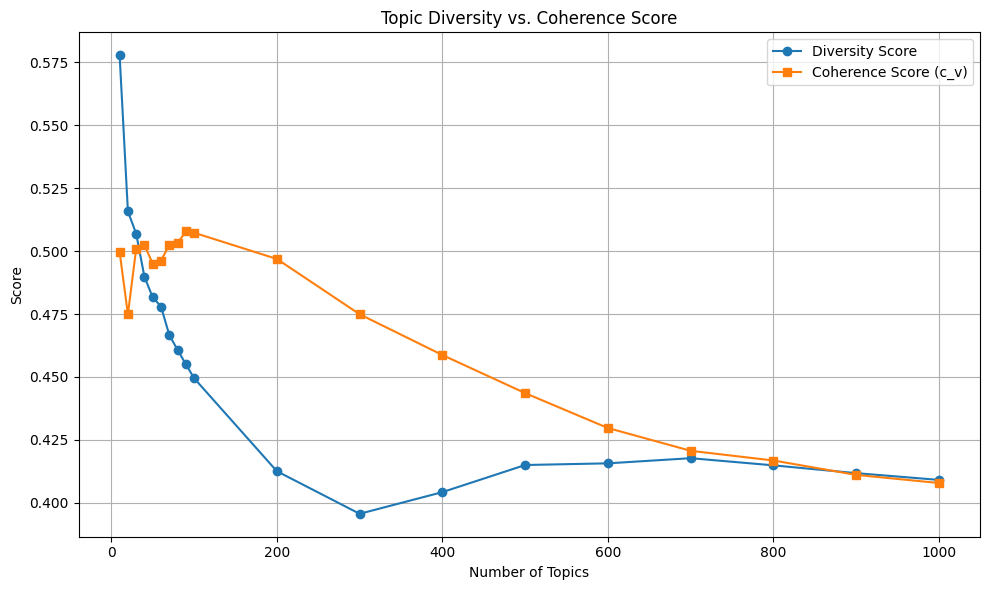

In [ ]:
reduced_model = BERTopic.load("../Model/bertopic_mcs=10_ms=10_nn=15_nc=5_md=0.0_nr=1,2_mid=3_updated_after_reduce_outliers")

topic_number_analysis(reduced_model, docs,
                      topic_nums=[10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])

In [57]:
topic_model.reduce_topics(docs, nr_topics=90)

In [58]:
topic_model_analysis(topic_model, docs)

Total documents: 113940
Documents assigned to topic -1: 8784 (7.71%)

Topic Diversity Score: 0.4551

Topic Summary:
    Topic  Count                                         Name  \
0      -1   8784                       -1_and_to_building_the   
1       0  59438                     0_of_and_storey_erection   
2       1   5979                     1_dormer_rear_front_roof   
3       2   3969          2_certificate_lawfulness_lawful_for   
4       3   3270    3_maisonette_conversion_floor_maisonettes   
..    ...    ...                                          ...   
85     84     30             84_stoke_newington_wilmer_window   
86     85     27                      85_scout_hut_hall_cadet   
87     86     21  86_discharge_attached_conditions_permission   
88     87     17                   87_9190_a1_building_101sqm   
89     88     16                   88_havelock_walk_se23_live   

                                       Representation  \
0   [and, to, building, the, new, of, floor, a

In [59]:
topic_model.visualize_documents(docs, reduced_embeddings=reduced_embeddings,
                                hide_document_hover=True, hide_annotations=True)

In [60]:
topic_model.save("../Model/bertopic_mcs=10_ms=10_nn=15_nc=5_md=0.0_nr=1,2_mid=3_final", save_embedding_model=True)

2025-07-11 15:59:02,066 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


In [ ]:
topic_model.visualize_barchart(top_n_topics=10)

In [ ]:
topic_model.visualize_topics()

In [ ]:
final_model = BERTopic.load("../Model/bertopic_mcs=10_ms=10_nn=15_nc=5_md=0.0_nr=1,2_mid=3_final")

In [ ]:
topic_final, probs_final = final_model.transform(docs)

In [ ]:
df_topic_distribution = pd.DataFrame(probs_final)
df_topic_distribution['lsoa'] = agg_text_train['lsoa21cd']
df_topic_distribution['year'] = agg_text_train['year']

df_topic_distribution.to_csv("../Output/Description extraction_origin.csv", index=False)

In [ ]:
lsoa_year_topic = df_topic_distribution.groupby(['lsoa', 'year']).mean().reset_index()

lsoa_year_topic.to_csv("../Output/Description extraction_grouped.csv", index=False)